In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

plt.style.use('../plotstyling.mplstyle')

In [3]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
ds = xr.open_dataset(db_filename)

In [4]:
NEDeltaT = np.array([0.36, 0.50, 0.56, 0.79, 0.84, 1.0, 0.80, 0.95, 1.53, 1.6])

Fwp = ds.Fwp.values
Fwc = ds.Fwc.values
Zm = ds.Fwp_Zm.values / 1000
Latitude = ds.Latitude.values
Longitude = ds.Longitude.values
Surf_z = ds.Surf_Z.values
altitude = ds.vertical_level.values / 1000
altitude_in_m = ds.vertical_level.values

channels = ["AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:,i] = ds[f"Ta_Allsky_{ch}"].values

CS_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array[:,i] = ds[f"Ta_Clearsky_{ch}"].values - ds[f"Ta_Allsky_{ch}"].values

CS_diff_array = np.zeros((Latitude.shape[0], len(channels)-1))
for i in range(len(channels)-1):
    CS_diff_array[:,i] = CS_array[:,i] - CS_array[:,i+1]

CS_bins = np.linspace(-5,5,100)

CS_diff_bins = np.linspace(-10,50,100)

deviation_bins = np.linspace(-10, 10, 101)
deviation_bins_centre = deviation_bins[:-1] + np.diff(deviation_bins) / 2

In [22]:
fwp_masks = [
    (Fwp < 1e-2),
    ((Fwp >= 1e-2) & (Fwp < 1e-1)),
    ((Fwp >= 1e-1) & (Fwp < 1e0)),
    (Fwp >= 1e0),
]


masks = [
    (np.abs(Latitude) < 60) & fwp_mask for fwp_mask in fwp_masks
]

mask_labels = [
    "Cloud-free",
    "Low Fwp",
    "Mid Fwp",
    "High Fwp",
]

In [23]:
threshold = 2  # K

for label, mask in zip(mask_labels, masks):
    total = mask.sum()
    # any channel (excluding AWS31, index 0) above threshold
    detected = mask & (np.any(CS_array[:, 1:] > threshold, axis=1))
    remaining = total - detected.sum()
    print(f"{label}: {remaining} / {total} remaining ({100*remaining.sum()/total:.1f}%)")

Cloud-free: 4086280 / 4112659 remaining (99.4%)
Low Fwp: 448344 / 659797 remaining (68.0%)
Mid Fwp: 46536 / 426235 remaining (10.9%)
High Fwp: 490 / 134375 remaining (0.4%)


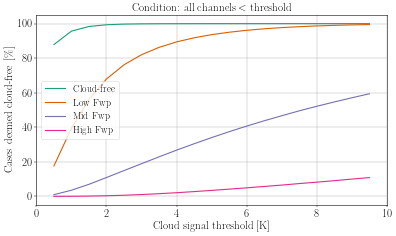

In [24]:
thresholds = np.arange(0.5, 10, 0.5)

fig, ax = plt.subplots(figsize=(10, 6))
for i, (label, mask) in enumerate(zip(mask_labels, masks)):
    total = mask.sum()
    rates = [
        100*(mask & np.all(CS_array[:, 1:] < t, axis=1)).sum() / total
        for t in thresholds
    ]
    ax.plot(thresholds, rates, color=f"C{i}", label=label, lw=2)

ax.set_xlabel("Cloud signal threshold [K]")
ax.set_ylabel(r"Cases deemed cloud-free [\%]")
ax.set_title(r"Condition: all channels $<$ threshold")
ax.legend()
ax.set_xlim([0,10])
ax.grid()
plt.tight_layout()
plt.savefig("../figures/CS_cloudfree_rate.png", dpi=200, bbox_inches="tight", facecolor="white")

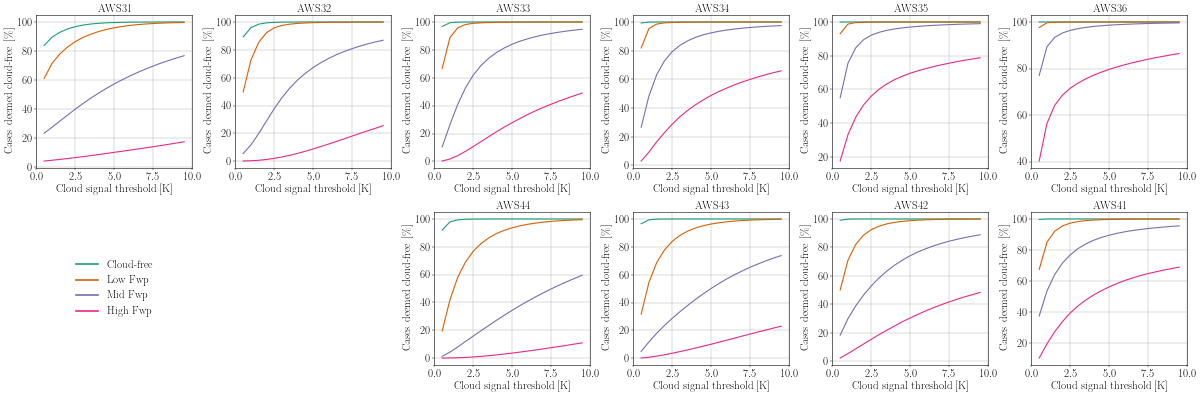

In [25]:
thresholds = np.arange(0.5, 10, 0.5)

fig, axes_2d = plt.subplots(2, 6, figsize=(30, 10))

for j, ch in enumerate(channels):
    if int(ch[-2:]) < 40:
        ax = axes_2d[0, j]
    else:
        ax = axes_2d[1, j-4]

    for i, (label, mask) in enumerate(zip(mask_labels, masks)):
        total = mask.sum()
        rates = [
            100 * (mask & (CS_array[:, j] < t)).sum() / total
            for t in thresholds
        ]
        ax.plot(thresholds, rates, color=f"C{i}", label=label, lw=2)

    ax.set_title(f"{ch}")
    ax.set_xlabel("Cloud signal threshold [K]")
    ax.set_ylabel("Cases deemed cloud-free [\%]")
    ax.set_xlim([0, 10])
    ax.grid()

# ── legend subplot ──
axes_2d[1, 1].set_visible(False)
axes_2d[1, 0].set_visible(True)
axes_2d[1, 0].axis("off")
handles = [plt.Line2D([0], [0], color=f"C{i}", label=mask_labels[i])
           for i in range(len(masks))]
axes_2d[1, 0].legend(handles=handles, loc="center", frameon=False, fontsize=20)

#fig.suptitle(r"Cases deemed cloud-free per channel vs threshold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/CS_cloudfree_rate_per_channel.png",
            dpi=200, bbox_inches="tight", facecolor="white")